Part A: Cubic Spine Interpolation
  n = 20 data points → 18 interior knots
  System size: 18 x 18 (interior second derivatives)
  Boundary conditions: M[0] = M[n-1] = 0 (natural spline)
  Continuity: C0, C1, C2 at each interior knot
  Second derivatives M: [   0.        6.5477   -3.3909   -3.7842   10.1276  -10.9261    1.7768
    6.8189   -8.0523    3.1905    2.4904   -2.9521    5.7179  -72.7196
  196.3605 -203.3224   80.5292   -1.1945   -4.3514    0.    ]
  Max interpolation error at knots: 7.11e-15


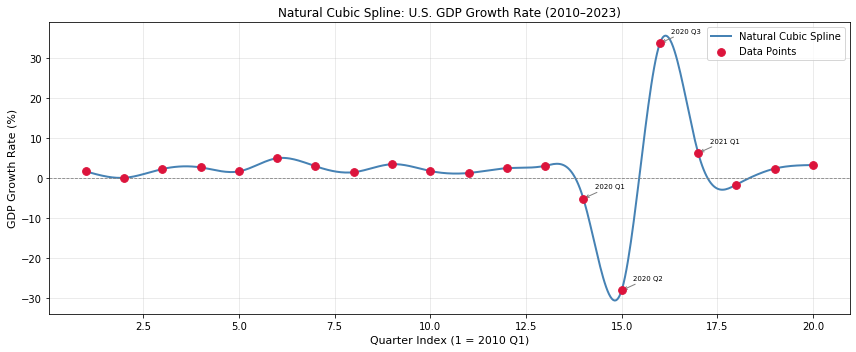

Part B: POLYNOMIAL & LEAST SQUARES COMPARISON

Fitting degree-4 polynomial
  Polynomial degree 4 | Condition number of A^T A: 2.3325e+11
  Degree-4 polynomial coefficients (c0 + c1*x + ... + c4*x^4):
    c0 = -4.137371
    c1 = 4.442419
    c2 = -0.823720
    c3 = 0.054471
    c4 = -0.001172
  RMSE (degree-4 polynomial): 9.9653%
  RMSE (cubic spline):        1.5896e-15% (interpolates exactly)


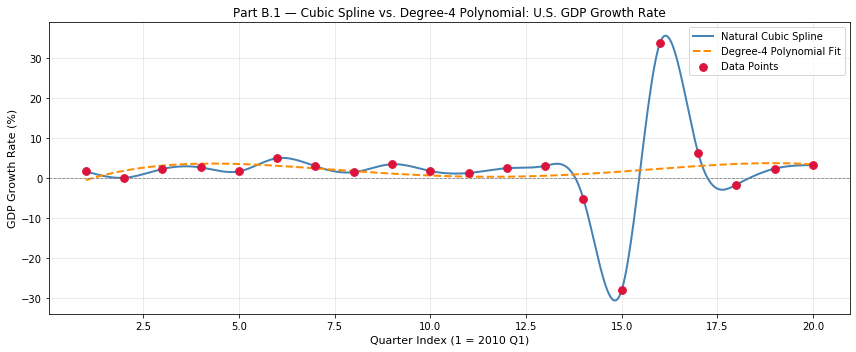

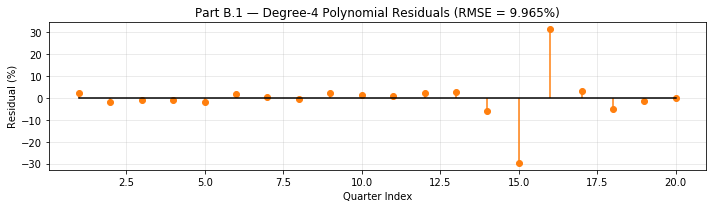


B.2: Fitting linear least squares model EXCLUDING COVID quarters...
  Slope  m = -0.017336  (% GDP change per quarter)
  Intercept b = 2.304112
  RMSE (linear, no COVID): 1.4400%


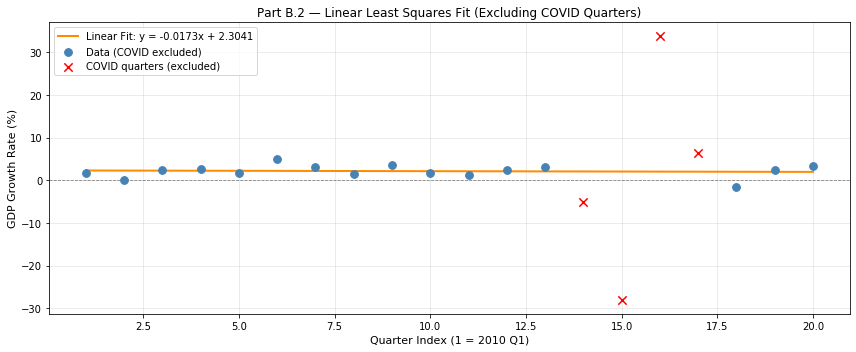

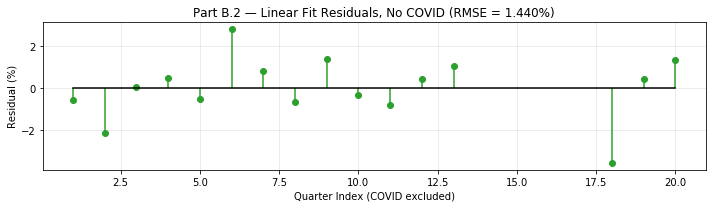

Part C: Method Justification

Method                              RMSE (%)        Big-O (build)        Big-O (eval)
-------------------------------------------------------------------------------------
Natural Cubic Spline                ~0 (exact)      O(n)                 O(n log n)
Degree-4 Polynomial (LS)            9.9653          O(n·d^2)             O(d)
Linear Least Squares (no COVID)     1.4400          O(n)                 O(1)

  Condition number of A^T A (degree-4): 2.3325e+11


In [5]:
# Mrinal Pradhan (mp53349)
# Midterm Project

import numpy as np
import matplotlib.pyplot as plt

# Dataset

quarter_labels = [
    "2010 Q1", "2011 Q1", "2012 Q1", "2013 Q1",
    "2014 Q1", "2014 Q3", "2015 Q2", "2016 Q1",
    "2016 Q3", "2016 Q4", "2017 Q1", "2018 Q1",
    "2019 Q1", "2020 Q1", "2020 Q2", "2020 Q3",
    "2021 Q1", "2022 Q1", "2023 Q2", "2023 Q4"]

gdp_values = [
    1.7,  0.1,  2.3,  2.7,
    1.7,  5.0,  3.0,  1.5,
    3.5,  1.8,  1.3,  2.5,
    3.1, -5.1, -28.1, 33.8,
    6.3, -1.6,  2.4,  3.3]

# Consecutive integer indices as x-values (avoids poor conditioning)
x_data = np.arange(1, len(gdp_values) + 1, dtype=float)
y_data = np.array(gdp_values, dtype=float)

# COVID quarter indices 
covid_indices = [14, 15, 16, 17]  
covid_mask = np.zeros(len(x_data), dtype=bool)
covid_mask[13:17] = True  

# Thomas Algorihim (Tridiagonal Solver)
def thomas_algorithm(a, b, c, d):
    n = len(d)
    ac = np.array(a, dtype=float)
    bc = np.array(b, dtype=float)
    cc = np.array(c, dtype=float)
    dc = np.array(d, dtype=float)

    # Forward elimination: eliminate sub-diagonal
    for i in range(1, n):
        factor = ac[i] / bc[i - 1]
        bc[i] -= factor * cc[i - 1]
        dc[i] -= factor * dc[i - 1]

    # Back substitution
    x = np.zeros(n)
    x[-1] = dc[-1] / bc[-1]
    for i in range(n - 2, -1, -1):
        x[i] = (dc[i] - cc[i] * x[i + 1]) / bc[i]
    return x

# Cubic Spine Interpolation
def cubic_spline_coefficients(x, y):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    n = len(x)
    if n < 3:
        raise ValueError("Need at least 3 data points for cubic spline.")

    h = np.diff(x)  # interval widths h[i] = x[i+1] - x[i]
    m = n - 2       # number of interior knots
    a = np.zeros(m)  # sub-diagonal
    b = np.zeros(m)  # main diagonal
    c = np.zeros(m)  # super-diagonal
    d = np.zeros(m)  # RHS

    for i in range(1, n - 1):
        row = i - 1
        if row > 0:
            a[row] = h[i - 1]
        b[row] = 2.0 * (h[i - 1] + h[i])
        if row < m - 1:
            c[row] = h[i]
        d[row] = 6.0 * ((y[i + 1] - y[i]) / h[i] - (y[i] - y[i - 1]) / h[i - 1])

    # Solve for second derivatives
    M = np.zeros(n)
    if m > 0:
        M[1:n - 1] = thomas_algorithm(a, b, c, d)
    return M


def evaluate_spline(x, y, M, x_eval):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    if x_eval <= x[0]:
        i = 0
    elif x_eval >= x[-1]:
        i = len(x) - 2
    else:
        i = np.searchsorted(x, x_eval) - 1 
    h = x[i + 1] - x[i]
    # Cubic spline formula
    term1 = M[i]     * (x[i + 1] - x_eval) ** 3 / (6.0 * h)
    term2 = M[i + 1] * (x_eval   - x[i])   ** 3 / (6.0 * h)
    term3 = (y[i]     - M[i]     * h ** 2 / 6.0) * (x[i + 1] - x_eval) / h
    term4 = (y[i + 1] - M[i + 1] * h ** 2 / 6.0) * (x_eval   - x[i])   / h
    return term1 + term2 + term3 + term4


def evaluate_spline_array(x, y, M, x_eval_arr):
    return np.array([evaluate_spline(x, y, M, xi) for xi in x_eval_arr])

# Polynomial Fitting: Vandermode
def vandermonde_matrix(x, degree):
    n = len(x)
    A = np.ones((n, degree + 1))
    for j in range(1, degree + 1):
        A[:, j] = x ** j
    return A


def polynomial_fit(x, y, degree):
    A = vandermonde_matrix(x, degree)
    ATA = A.T @ A          
    ATy = A.T @ y          
    cond = np.linalg.cond(ATA)
    print(f"  Polynomial degree {degree} | Condition number of A^T A: {cond:.4e}")
    coeffs = np.linalg.solve(ATA, ATy)
    return coeffs, cond


def evaluate_polynomial(coeffs, x_eval):
    result = np.zeros_like(x_eval, dtype=float)
    for j, c in enumerate(coeffs):
        result += c * x_eval ** j
    return result


# Least Squares Regression
def least_squares_linear(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x_mean = x.mean()
    y_mean = y.mean()
    denom = np.sum((x - x_mean) ** 2)
    if denom == 0:
        raise ValueError("All x values are identical; cannot fit a line.")
    m = np.sum((x - x_mean) * (y - y_mean)) / denom
    b = y_mean - m * x_mean
    y_hat = m * x + b
    residuals = y - y_hat
    return m, b, residuals, y_hat

def rmse(residuals):
    return np.sqrt(np.mean(residuals ** 2))


# Part A: Cubic Spine Interpolation
# 1.
print("Part A: Cubic Spine Interpolation")

# Build the natural cubic spline through dataset
print(f"  n = {len(x_data)} data points → {len(x_data)-2} interior knots")
print(f"  System size: {len(x_data)-2} x {len(x_data)-2} (interior second derivatives)")
print("  Boundary conditions: M[0] = M[n-1] = 0 (natural spline)")
print("  Continuity: C0, C1, C2 at each interior knot")

M_spline = cubic_spline_coefficients(x_data, y_data)
print(f"  Second derivatives M: {np.round(M_spline, 4)}")

# Evaluate at fine grid over the full 20-point range
x_fine = np.linspace(x_data[0], x_data[-1], 500)
y_spline_fine = evaluate_spline_array(x_data, y_data, M_spline, x_fine)

# Spline residuals at knot points 
y_spline_at_knots = evaluate_spline_array(x_data, y_data, M_spline, x_data)
spline_residuals = y_data - y_spline_at_knots
print(f"  Max interpolation error at knots: {np.max(np.abs(spline_residuals)):.2e}")

# 2. 
# Plot spline evaluated over full range
fig, axes = plt.subplots(1, 1, figsize=(12, 5))
axes.scatter(x_data, y_data, color='crimson', zorder=5, s=60, label="Data Points")
axes.plot(x_fine, y_spline_fine, color='steelblue', lw=2, label="Natural Cubic Spline")
axes.axhline(0, color='gray', lw=0.8, linestyle='--')

# Annotate COVID quarters
for idx_0based, lbl in zip([13, 14, 15, 16], ["2020 Q1", "2020 Q2", "2020 Q3", "2021 Q1"]):
    axes.annotate(lbl, xy=(x_data[idx_0based], y_data[idx_0based]),
                  xytext=(x_data[idx_0based] + 0.3, y_data[idx_0based] + 2.5),
                  fontsize=7, arrowprops=dict(arrowstyle='->', color='gray'))

axes.set_xlabel("Quarter Index (1 = 2010 Q1)", fontsize=11)
axes.set_ylabel("GDP Growth Rate (%)", fontsize=11)
axes.set_title("Natural Cubic Spline: U.S. GDP Growth Rate (2010–2023)", fontsize=12)
axes.legend()
axes.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Part B: Polynomial & Least Squares Comparison
print("Part B: Polynomial & Least Squares Comparison")

# 1. 
# Degree-4 Polynomial Fit 
print("\nFitting degree-4 polynomial")
deg = 4
coeffs4, cond4 = polynomial_fit(x_data, y_data, deg)
y_poly4 = evaluate_polynomial(coeffs4, x_fine)
y_poly4_at_data = evaluate_polynomial(coeffs4, x_data)
poly4_residuals = y_data - y_poly4_at_data
rmse_poly4 = rmse(poly4_residuals)
rmse_spline = rmse(spline_residuals)

print(f"  Degree-4 polynomial coefficients (c0 + c1*x + ... + c4*x^4):")
for i, c in enumerate(coeffs4):
    print(f"    c{i} = {c:.6f}")
print(f"  RMSE (degree-4 polynomial): {rmse_poly4:.4f}%")
print(f"  RMSE (cubic spline):        {rmse_spline:.4e}% (interpolates exactly)")

# Plot: spline vs degree-4 polynomial
fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(x_data, y_data, color='crimson', zorder=5, s=60, label="Data Points")
ax.plot(x_fine, y_spline_fine, color='steelblue', lw=2, label="Natural Cubic Spline")
ax.plot(x_fine, y_poly4,       color='darkorange', lw=2, linestyle='--', label="Degree-4 Polynomial Fit")
ax.axhline(0, color='gray', lw=0.8, linestyle='--')
ax.set_xlabel("Quarter Index (1 = 2010 Q1)", fontsize=11)
ax.set_ylabel("GDP Growth Rate (%)", fontsize=11)
ax.set_title("Part B.1 — Cubic Spline vs. Degree-4 Polynomial: U.S. GDP Growth Rate", fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Residual plot for degree-4 polynomial
fig, ax = plt.subplots(figsize=(10, 3))
ax.stem(x_data, poly4_residuals, linefmt='C1-', markerfmt='C1o', basefmt='k-', use_line_collection=True)
ax.set_xlabel("Quarter Index")
ax.set_ylabel("Residual (%)")
ax.set_title(f"Part B.1 — Degree-4 Polynomial Residuals (RMSE = {rmse_poly4:.3f}%)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2.
# Excludes covid
print("\Fitting linear least squares model excluding covid.")
x_no_covid = x_data[~covid_mask]
y_no_covid = y_data[~covid_mask]

m_lin, b_lin, res_lin, yhat_lin = least_squares_linear(x_no_covid, y_no_covid)
rmse_lin = rmse(res_lin)

print(f"  Slope  m = {m_lin:.6f}  (% GDP change per quarter)")
print(f"  Intercept b = {b_lin:.6f}")
print(f"  RMSE (linear, no COVID): {rmse_lin:.4f}%")

x_line_full = np.linspace(x_data[0], x_data[-1], 300)
y_line_full = m_lin * x_line_full + b_lin

fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(x_no_covid, y_no_covid, color='steelblue', s=60, zorder=5, label="Data (COVID excluded)")
ax.scatter(x_data[covid_mask], y_data[covid_mask], color='red', s=70, marker='x',
           zorder=5, linewidths=2, label="COVID quarters (excluded)")
ax.plot(x_line_full, y_line_full, color='darkorange', lw=2,
        label=f"Linear Fit: y = {m_lin:.4f}x + {b_lin:.4f}")
ax.axhline(0, color='gray', lw=0.8, linestyle='--')
ax.set_xlabel("Quarter Index (1 = 2010 Q1)", fontsize=11)
ax.set_ylabel("GDP Growth Rate (%)", fontsize=11)
ax.set_title("Part B.2 — Linear Least Squares Fit (Excluding COVID Quarters)", fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Residual plot for linear fit (no COVID)
fig, ax = plt.subplots(figsize=(10, 3))
ax.stem(x_no_covid, res_lin, linefmt='C2-', markerfmt='C2o', basefmt='k-', use_line_collection=True)
ax.set_xlabel("Quarter Index (COVID excluded)")
ax.set_ylabel("Residual (%)")
ax.set_title(f"Part B.2 — Linear Fit Residuals, No COVID (RMSE = {rmse_lin:.3f}%)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Part C: Method Justification
print("Part C: Method Justification")
print(f"\n{'Method':<35} {'RMSE (%)':<15} {'Big-O (build)':<20} {'Big-O (eval)'}")
print("-" * 85)
print(f"{'Natural Cubic Spline':<35} {'~0 (exact)':<15} {'O(n)':<20} {'O(n log n)'}")
print(f"{'Degree-4 Polynomial (LS)':<35} {rmse_poly4:<15.4f} {'O(n·d^2)':<20} {'O(d)'}")
print(f"{'Linear Least Squares (no COVID)':<35} {rmse_lin:<15.4f} {'O(n)':<20} {'O(1)'}")
print(f"\n  Condition number of A^T A (degree-4): {cond4:.4e}")

